# Retirement Planning Demo &mdash; `example01.json`

A clean, decision-focused walk-through of the **`tax_optimizer`** package.

This notebook loads the household scenario from
[`scenarios/example01.json`](scenarios/example01.json), runs the four
canonical strategies (S0/S1/S2/S3), stresses the plan against
mortality and tax-regime risk, and ends with a markdown action report
you can hand to your tax advisor.

> **Tip:** to model a different household, **edit the JSON file** —
> all the inputs live there. The notebook itself is just glue.

**Contents**

1. Setup &amp; load scenario
2. Household snapshot
3. First-year sanity check
4. Strategy comparison (S0 &mdash; S3)
5. Year-by-year detail (winning strategy)
6. Visualizations
7. Tornado sensitivity
8. Monte Carlo &mdash; sequence-of-returns risk
9. Widow's-penalty stress test
10. TCJA sunset stress test
11. Tier&nbsp;C feature dial &mdash; ACA / step-up / state / IRMAA
12. Decision-ready action report
13. What's new in v5

## §0. Setup

In [45]:
from __future__ import annotations

import json
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from tax_optimizer import (
    Config, Inputs,
    simulate, simulate_paths,
    Mortality, SocialSecurity, SpendingProfile, StartingBalances,
    LognormalModel, BootstrapModel, HistoricalSequenceModel, AssetLocation,
    SUNSET_2026, TCJA_EXTENDED, PRE_TCJA_2017,
)
from tax_optimizer.metrics import summarize, terminal_after_tax_nw
from tax_optimizer.optimizer import optimize_household
from tax_optimizer.results import StrategyResult
from tax_optimizer.scenario import apply_scenario
from tax_optimizer.sensitivity import tornado_sensitivity
from tax_optimizer.report import build_action_report
from tax_optimizer.tax.state import CA, NY, IL, MA, STATELESS

pd.options.display.float_format = "{:,.0f}".format
plt.rcParams["figure.dpi"] = 100

## §1. Load scenario

In [46]:
scenario_path = Path("scenarios/example01.json")
with open(scenario_path) as f:
    scenario = json.load(f)

cfg, inputs = apply_scenario(Config(), Inputs(), scenario)

horizon = cfg.horizon_age - inputs.spouse_a_age_start + 1
print(f"Loaded {scenario_path}")
print(f"  horizon:            {horizon} years (ages {inputs.spouse_a_age_start} / {inputs.spouse_b_age_start} \u2192 {cfg.horizon_age})")
print(f"  federal regime:     {cfg.tax_regime.name}", end="")
if cfg.regime_change_year_offset is not None:
    print(f" \u2192 {cfg.regime_change_target.name} in year offset {cfg.regime_change_year_offset}")
else:
    print()
print(f"  state regime:       {cfg.state_regime.name}")
print(f"  withdrawal order:   {cfg.withdrawal_strategy}")
print(f"  market model:       {type(cfg.market).__name__}")

Loaded scenarios/example01.json
  horizon:            44 years (ages 52 / 50 → 95)
  federal regime:     TCJA_extended_2026 → tcja_sunset_2026 in year offset 5
  state regime:       stateless
  withdrawal order:   conventional
  market model:       LognormalModel


## §2. Household snapshot

A one-glance view of the inputs the simulator is starting from.

In [47]:
total_pretax = (
    inputs.starting.spouse_a_pretax_401k + inputs.starting.spouse_b_pretax_401k
    + inputs.starting.spouse_a_pretax_ira + inputs.starting.spouse_b_pretax_ira
)
total_roth = inputs.starting.spouse_a_roth_ira + inputs.starting.spouse_b_roth_ira
gross_w2 = inputs.income.spouse_a_gross + inputs.income.spouse_b_gross + inputs.income.spouse_a_bonus
total_liquid = total_pretax + total_roth + inputs.starting.taxable_brokerage + inputs.starting.hsa

snapshot = pd.Series({
    "Spouse A age (retire / SS claim)":  f"{inputs.spouse_a_age_start} ({inputs.spouse_a_retire_age} / {inputs.ss.effective_start_age_a})",
    "Spouse B age (retire / SS claim)":  f"{inputs.spouse_b_age_start} ({inputs.spouse_b_retire_age} / {inputs.ss.effective_start_age_b})",
    "Combined gross W-2 (today)":        f"${gross_w2:,.0f}",
    "Annual expenses (today)":           f"${cfg.resolved_spending().base_spending:,.0f}",
    "Pretax 401(k) + IRA":               f"${total_pretax:,.0f}",
    "Roth IRA":                          f"${total_roth:,.0f}",
    "Taxable brokerage":                 f"${inputs.starting.taxable_brokerage:,.0f}",
    "HSA":                               f"${inputs.starting.hsa:,.0f}",
    "Pension cash balance":              f"${inputs.starting.pension_balance:,.0f}",
    "Total invested":                    f"${total_liquid:,.0f}",
    "Roth-401(k) split (A / B)":         f"{inputs.spouse_a_roth_401k_pct:.0%} / {inputs.spouse_b_roth_401k_pct:.0%}",
    "Mega-backdoor enabled (A / B)":     f"{inputs.spouse_a_mega_backdoor_enabled} / {inputs.spouse_b_mega_backdoor_enabled}",
    "Backdoor IRA enabled (A / B)":      f"{inputs.spouse_a_backdoor_roth} / {inputs.spouse_b_backdoor_roth}",
}, name="value")
display(snapshot.to_frame())

,value
Spouse A age (retire / SS claim),52 (65 / 70)
Spouse B age (retire / SS claim),50 (67 / 67)
Combined gross W-2 (today),"$250,000"
Annual expenses (today),"$95,000"
Pretax 401(k) + IRA,"$650,000"
Roth IRA,"$60,000"
Taxable brokerage,"$120,000"
HSA,"$25,000"
Pension cash balance,$0
Total invested,"$855,000"


## §3. First-year sanity check

Verify the simulator agrees with your latest pay stub: wages, marginal
rate, FICA, and the contributions actually ending up in each bucket.
If anything here looks off, fix the JSON before reading the rest of the
notebook.

In [48]:
df_baseline = simulate(cfg, inputs)
y0 = df_baseline.iloc[0]

emp_401k = y0.get("elective_deferral_a", 0) + y0.get("elective_deferral_b", 0)
empr_match = y0.get("employer_match_a", 0) + y0.get("employer_match_b", 0)
mega_bd = y0.get("mega_backdoor_a", 0) + y0.get("mega_backdoor_b", 0)
bd_ira = y0.get("ira_backdoor_a", 0) + y0.get("ira_backdoor_b", 0)

print(f"Year 1 ({y0['year']:.0f}, ages {y0['spouse_a_age']:.0f}/{y0['spouse_b_age']:.0f}, filing={y0['filing_status']}):")
print()
print("  Income side:")
print(f"    Wages (Box 1)                ${y0['wages']:>12,.0f}")
print(f"    AGI                          ${y0['agi']:>12,.0f}    (peak marginal {y0['marginal']:.0%})")
print(f"    Taxable income               ${y0['taxable_income']:>12,.0f}")
print()
print("  Tax / FICA:")
print(f"    Federal tax                  ${y0['federal_tax']:>12,.0f}")
print(f"    State tax                    ${y0['state_tax']:>12,.0f}    (regime: {y0['state_regime']})")
print(f"    FICA OASDI                   ${y0['fica_oasdi']:>12,.0f}")
print(f"    FICA Medicare                ${y0['fica_medicare']:>12,.0f}")
print(f"    Add'l Medicare 0.9% (MFJ)    ${y0['fica_additional_medicare']:>12,.0f}")
print()
print("  Tax-advantaged contributions:")
print(f"    401(k) employee + employer   ${emp_401k + empr_match:>12,.0f}")
print(f"    Mega-backdoor Roth           ${mega_bd:>12,.0f}")
print(f"    Backdoor Roth IRA            ${bd_ira:>12,.0f}")
print(f"    HSA                          ${y0['hsa_contrib']:>12,.0f}")

Year 1 (2026, ages 52/50, filing=mfj):

  Income side:
    Wages (Box 1)                $     250,000
    AGI                          $     213,764    (peak marginal 22%)
    Taxable income               $     181,564

  Tax / FICA:
    Federal tax                  $      29,692
    State tax                    $           0    (regime: stateless)
    FICA OASDI                   $      14,431
    FICA Medicare                $       3,375
    Add'l Medicare 0.9% (MFJ)    $           0

  Tax-advantaged contributions:
    401(k) employee + employer   $      28,650
    Mega-backdoor Roth           $           0
    Backdoor Roth IRA            $           0
    HSA                          $       8,550


## §4. Strategy comparison &mdash; S0, S1, S2, S3

The four canonical strategies the package lets you compare apples-to-apples:

| Strategy | What it does |
|---|---|
| **S0_baseline** | Exactly the JSON inputs &mdash; no overrides. |
| **S1_all_roth** | Both spouses contribute 100% of their 401(k) as Roth. |
| **S2_bracket_fill_22** | Fill the 22% federal bracket with Roth conversions in retirement. |
| **S3_optimizer** | Let `optimize_household` search the joint Roth-split / conversion / mega-backdoor / SS-claim space. |

Optimization is bounded by `maxiter` and `popsize` &mdash; small here so the
notebook stays interactive. Crank both up for production planning.

> ### What the optimizer is actually maximizing
>
> The default `objective="terminal"` maximizes
>
> $$\text{terminal\_after\_tax\_NW} - 1000 \cdot \text{deficit} - 0.5 \cdot \text{IRMAA}_{\text{total}}$$
>
> where `terminal_after_tax_NW` weighs the four end-of-horizon buckets
> by their *bequest* tax cost &mdash; not their face value:
>
> | Bucket   | Counted at horizon as |
> |----------|-----------------------|
> | Roth     | $1.00 per dollar (tax-free to heirs) |
> | Taxable  | $1.00 per dollar (step-up at death) |
> | HSA      | $(1 - r)$ per dollar (ordinary income to non-spouse heirs) |
> | Pretax   | $(1 - r)$ per dollar (10-year SECURE-Act drain at heir's bracket) |
>
> with $r$ = `cfg.heir_marginal_rate` (**default 0.22**).
>
> **This is how taxes-paid-now is weighed against pretax growth.** Each
> dollar that *stays* in pretax grows tax-deferred but only counts as
> $0.78 at horizon. Each dollar moved to Roth (via contribution or
> conversion) costs tax today, but counts at full $1.00 at horizon. So
> a Roth-heavy plan that pays *more* lifetime federal tax can still win
> because the after-tax wealth at horizon is larger. **Lifetime tax NPV
> is reported but is *not* a term in the objective.**
>
> The single knob to tune this trade-off is **`cfg.heir_marginal_rate`**:
>
> | Set it to | Implies | Optimizer leans toward |
> |-----------|---------|------------------------|
> | 0.10  | "My kids will be in a low bracket" | Keep money pretax |
> | 0.22 *(default)* | Adult-child typical bracket | Balanced |
> | 0.32&ndash;0.37 | "TCJA sunsets and my heirs are high earners" | Aggressive Roth conversions |
>
> The CVaR (`objective="cvar"`) and probability-of-success
> (`objective="p_success"`) variants apply the same bequest-tax logic
> per Monte-Carlo path; CVaR optimizes the worst-decile tail rather
> than the median.

In [49]:
s0_cfg, s0_inputs = cfg, inputs

s1_inputs = replace(inputs, spouse_a_roth_401k_pct=1.0, spouse_b_roth_401k_pct=1.0)
s1_cfg = cfg

s2_cfg = replace(cfg, roth_conversion_target_bracket=0.22, roth_conversion_amount=0.0)
s2_inputs = inputs

print("Optimizing S3 (terminal-NW objective) \u2014 ~5\u201310 seconds...")
s3_cfg, s3_inputs, _x = optimize_household(
    cfg, inputs, objective="terminal", maxiter=20, popsize=10, seed=0,
)

results: dict[str, StrategyResult] = {}
for name, c, i in [
    ("S0_baseline",         s0_cfg, s0_inputs),
    ("S1_all_roth",         s1_cfg, s1_inputs),
    ("S2_bracket_fill_22",  s2_cfg, s2_inputs),
    ("S3_optimizer",        s3_cfg, s3_inputs),
]:
    df = simulate(c, i)
    s = summarize(df, heir_marginal_rate=c.heir_marginal_rate)
    results[name] = StrategyResult(cfg=c, inputs=i, df=df, summary=s)

cmp = pd.DataFrame({
    name: {
        "Terminal NW (after-tax)":   r.summary["terminal_after_tax"],
        "Lifetime federal tax NPV":  r.summary["lifetime_tax_npv"],
        "Lifetime IRMAA NPV":        r.summary["lifetime_irmaa_npv"],
        "Years with IRMAA":          r.summary["years_irmaa"],
        "Peak marginal rate":        f"{r.df['marginal'].max():.0%}",
    }
    for name, r in results.items()
}).T

display(cmp)

winner_name = max(results, key=lambda n: results[n].summary["terminal_after_tax"])
winner = results[winner_name]
print(f"\nWinner: {winner_name}  (terminal NW = ${winner.summary['terminal_after_tax']:,.0f})")
print(f"  vs S0 baseline:  +${winner.summary['terminal_after_tax'] - results['S0_baseline'].summary['terminal_after_tax']:,.0f}")

if winner_name == "S3_optimizer":
    print("\nWhat the optimizer chose:")
    print(f"  spouse_a_roth_401k_pct          = {winner.inputs.spouse_a_roth_401k_pct:.0%}")
    print(f"  spouse_b_roth_401k_pct          = {winner.inputs.spouse_b_roth_401k_pct:.0%}")
    print(f"  roth_conversion_target_bracket  = {winner.cfg.roth_conversion_target_bracket:.0%}")
    print(f"  spouse_a_after_tax_401k_pct     = {winner.inputs.spouse_a_after_tax_401k_pct:.1%}")
    print(f"  spouse_b_after_tax_401k_pct     = {winner.inputs.spouse_b_after_tax_401k_pct:.1%}")

Optimizing S3 (terminal-NW objective) — ~5–10 seconds...


,Terminal NW (after-tax),Lifetime federal tax NPV,Lifetime IRMAA NPV,Years with IRMAA,Peak marginal rate
S0_baseline,"7,676,948","1,556,893","58,123",16,28%
S1_all_roth,"9,265,230","1,612,588","57,056",17,28%
S2_bracket_fill_22,"7,807,899","1,513,587","51,769",16,28%
S3_optimizer,"10,245,351","1,279,809","16,364",8,28%



Winner: S3_optimizer  (terminal NW = $10,245,351)
  vs S0 baseline:  +$2,568,404

What the optimizer chose:
  spouse_a_roth_401k_pct          = 100%
  spouse_b_roth_401k_pct          = 100%
  roth_conversion_target_bracket  = 24%
  spouse_a_after_tax_401k_pct     = 0.0%
  spouse_b_after_tax_401k_pct     = 0.0%


## §5. Year-by-year detail (winning strategy)

Four representative slices: the working years, the gap years before
RMDs kick in (often the prime Roth-conversion window), the early-RMD
years, and the last few years.

In [50]:
df_w = winner.df

retire_age = max(winner.inputs.spouse_a_retire_age, winner.inputs.spouse_b_retire_age)
slices = {
    "Pre-retirement (first 5)":    df_w.head(5),
    "Gap years (retire \u2192 RMD)":  df_w[(df_w["spouse_a_age"] >= retire_age) & (df_w["spouse_a_age"] < winner.cfg.rmd_start_age)],
    "Early RMD years":             df_w[df_w["spouse_a_age"] >= winner.cfg.rmd_start_age].head(8),
    "Last 3 years":                df_w.tail(3),
}

detail_cols = [
    "year", "spouse_a_age", "filing_status",
    "wages", "pension", "ssn",
    "rmd", "roth_conversion",
    "pretax_withdrawal", "roth_withdrawal", "taxable_withdrawal",
    "agi", "federal_tax", "state_tax", "bracket",
    "irmaa", "medicare_base_premium", "spending_need",
    "pretax_balance", "roth_balance", "taxable_balance", "hsa_balance",
]

for label, sub in slices.items():
    if len(sub) == 0:
        continue
    print(f"\n\u2500\u2500\u2500 {label} \u2500\u2500\u2500")
    disp = sub.copy()
    # Format federal marginal rate as e.g. "22%" so it survives the
    # round-to-whole-dollars below (otherwise 0.22 -> 0). This is the
    # **current federal tax bracket** -- the rate the next dollar of
    # ordinary income would face.
    disp["bracket"] = disp["marginal"].apply(lambda r: f"{r*100:.0f}%")
    display(disp[detail_cols].round(0))


─── Pre-retirement (first 5) ───


,year,spouse_a_age,filing_status,wages,pension,ssn,rmd,roth_conversion,pretax_withdrawal,roth_withdrawal,...,federal_tax,state_tax,bracket,irmaa,medicare_base_premium,spending_need,pretax_balance,roth_balance,taxable_balance,hsa_balance
0,2026,52,mfj,"250,000",0,0,0,"191,436",0,0,...,"80,394",0,24%,0,0,"95,000","485,518","284,708","165,583","34,984"
1,2027,53,mfj,"257,500",0,0,0,"193,617",0,0,...,"82,403",0,24%,0,0,"97,375","293,398","490,927","202,645","42,695"
2,2028,54,mfj,"265,225",0,0,0,"196,024",0,0,...,"84,462",0,24%,0,0,"99,809","119,058","806,036","279,666","58,188"
3,2029,55,mfj,"273,182",0,0,0,"126,762",0,0,...,"69,568",0,24%,0,0,"102,305",0,"869,876","311,251","60,700"
4,2030,56,mfj,"281,377",0,0,0,"7,935",0,0,...,"42,587",0,24%,0,0,"104,862",0,"1,019,787","458,732","78,282"



─── Gap years (retire → RMD) ───


,year,spouse_a_age,filing_status,wages,pension,ssn,rmd,roth_conversion,pretax_withdrawal,roth_withdrawal,...,federal_tax,state_tax,bracket,irmaa,medicare_base_premium,spending_need,pretax_balance,roth_balance,taxable_balance,hsa_balance
15,2041,67,mfj,"148,007",0,0,0,0,0,0,...,"32,758",0,25%,0,"7,241","158,227","184,617","4,605,705","3,170,887","484,254"
16,2042,68,mfj,"152,447",0,0,0,0,0,0,...,"35,278",0,25%,0,"7,423","162,182","206,258","5,034,487","3,369,958","527,939"
17,2043,69,mfj,0,0,"45,649",0,0,0,0,...,"13,672",0,15%,0,"7,608","166,237","214,368","5,232,452","3,338,884","548,699"
18,2044,70,mfj,0,0,"118,734",0,0,0,0,...,"35,817",0,15%,0,"7,798","170,393","244,932","5,978,508","3,689,874","626,934"
19,2045,71,mfj,0,0,"121,702",0,0,0,0,...,"39,342",0,15%,0,"7,993","174,653","241,263","5,888,944","3,517,865","617,541"
20,2046,72,mfj,0,0,"124,745",0,0,0,0,...,"37,801",0,15%,0,"8,193","179,019","300,827","7,342,854","4,244,274","770,005"
21,2047,73,mfj,0,0,"127,863",0,0,0,0,...,"44,858",0,15%,0,"8,398","183,494","271,185","6,619,325","3,707,229","694,133"
22,2048,74,mfj,0,0,"131,060",0,0,0,0,...,"39,914",0,15%,0,"8,608","188,082","277,157","6,765,097","3,662,994","709,419"



─── Early RMD years ───


,year,spouse_a_age,filing_status,wages,pension,ssn,rmd,roth_conversion,pretax_withdrawal,roth_withdrawal,...,federal_tax,state_tax,bracket,irmaa,medicare_base_premium,spending_need,pretax_balance,roth_balance,taxable_balance,hsa_balance
23,2049,75,mfj,0,0,"134,336","5,933",0,"5,933",0,...,"35,015",0,15%,0,"8,823","150,874","245,825","6,131,567","3,252,580","642,984"
24,2050,76,mfj,0,0,"137,695","5,355",0,"5,355",0,...,"30,761",0,15%,0,"9,044","154,646","204,840","5,223,086","2,710,871","547,717"
25,2051,77,mfj,0,0,"141,137","8,639",0,"8,639",0,...,"25,374",0,15%,0,"9,270","158,512","195,324","5,199,724","2,642,223","545,267"
26,2052,78,mfj,0,0,"144,665","8,563",0,"8,563",0,...,"24,348",0,15%,0,"9,501","162,475","200,261","5,575,591","2,774,012","380,916"
27,2053,79,mfj,0,0,"148,282","9,121",0,"9,121",0,...,"26,067",0,15%,0,"9,739","166,537","235,556","6,871,224","3,349,597","229,390"
28,2054,80,mfj,0,0,"151,989","11,187",0,"11,187",0,...,"33,307",0,15%,0,"9,982","170,700","228,258","6,990,328","3,339,470","30,256"
29,2055,81,mfj,0,0,"155,789","11,294",0,"11,294",0,...,"53,359",0,15%,0,"10,232","349,353","260,744","8,400,840","3,702,370",0
30,2056,82,mfj,0,0,"96,757","12,908",0,"12,908",0,...,"19,582",0,15%,0,"5,244","179,342","272,068","9,222,225","3,942,584",0



─── Last 3 years ───


,year,spouse_a_age,filing_status,wages,pension,ssn,rmd,roth_conversion,pretax_withdrawal,roth_withdrawal,...,federal_tax,state_tax,bracket,irmaa,medicare_base_premium,spending_need,pretax_balance,roth_balance,taxable_balance,hsa_balance
41,2067,93,single,0,0,"126,953","8,657",0,"8,658",0,...,"23,144",0,15%,0,"6,880","261,458","99,222","7,231,847","1,246,025",0
42,2068,94,single,0,0,"130,127","9,187",0,"9,187",0,...,"25,243",0,15%,0,"7,052","267,995","111,179","8,930,240","1,334,447",0
43,2069,95,single,0,0,"133,380","11,008",0,"11,008",0,...,"32,798",0,15%,0,"7,229","274,694","100,946","8,999,316","1,167,298",0


In [51]:
df_w.to_csv("df_w.csv")

## §6. Visualizations

Four panels for the winning strategy:

- **Balance trajectory** &mdash; shows tax-bucket location over time
- **Tax line items** &mdash; federal vs state vs IRMAA vs base Medicare
- **Withdrawals + conversions** &mdash; the order of operations each year
- **Income vs spending need** &mdash; Social Security + pension vs the gap to fill

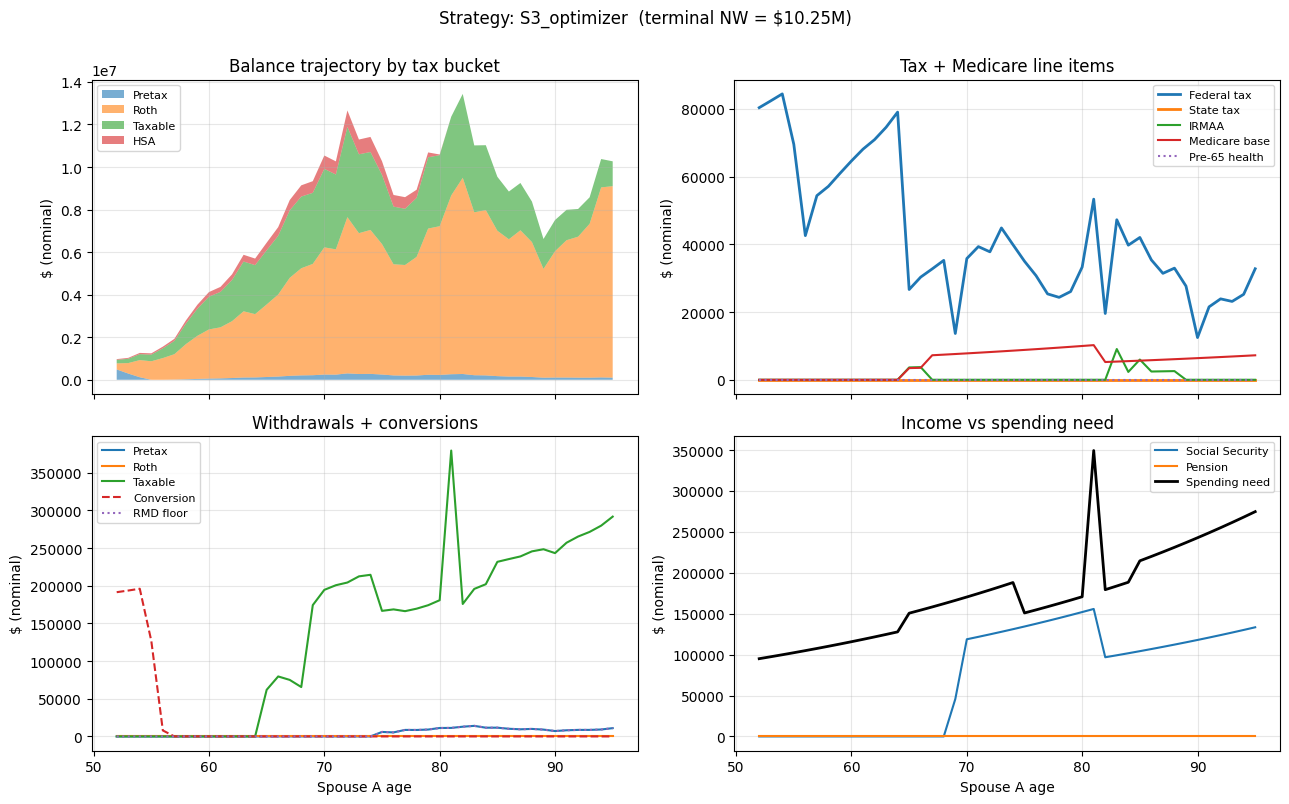

In [52]:
df = winner.df
ages = df["spouse_a_age"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

ax = axes[0, 0]
b1 = df["pretax_balance"]
b2 = b1 + df["roth_balance"]
b3 = b2 + df["taxable_balance"]
b4 = b3 + df["hsa_balance"]
ax.fill_between(ages, 0, b1, alpha=0.6, label="Pretax")
ax.fill_between(ages, b1, b2, alpha=0.6, label="Roth")
ax.fill_between(ages, b2, b3, alpha=0.6, label="Taxable")
ax.fill_between(ages, b3, b4, alpha=0.6, label="HSA")
ax.set_title("Balance trajectory by tax bucket")
ax.set_ylabel("$ (nominal)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(ages, df["federal_tax"], label="Federal tax", linewidth=2)
ax.plot(ages, df["state_tax"], label="State tax", linewidth=2)
ax.plot(ages, df["irmaa"], label="IRMAA")
ax.plot(ages, df["medicare_base_premium"], label="Medicare base")
ax.plot(ages, df["health_pre65"], label="Pre-65 health", linestyle=":")
ax.set_title("Tax + Medicare line items")
ax.set_ylabel("$ (nominal)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(ages, df["pretax_withdrawal"], label="Pretax")
ax.plot(ages, df["roth_withdrawal"], label="Roth")
ax.plot(ages, df["taxable_withdrawal"], label="Taxable")
ax.plot(ages, df["roth_conversion"], label="Conversion", linestyle="--")
ax.plot(ages, df["rmd"], label="RMD floor", linestyle=":")
ax.set_title("Withdrawals + conversions")
ax.set_xlabel("Spouse A age")
ax.set_ylabel("$ (nominal)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(ages, df["ssn"], label="Social Security")
ax.plot(ages, df["pension"], label="Pension")
ax.plot(ages, df["spending_need"], label="Spending need", linewidth=2, color="black")
ax.set_title("Income vs spending need")
ax.set_xlabel("Spouse A age")
ax.set_ylabel("$ (nominal)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.suptitle(f"Strategy: {winner_name}  (terminal NW = ${winner.summary['terminal_after_tax']/1e6:.2f}M)",
             y=1.0, fontsize=12)
plt.tight_layout()
plt.show()

## §7. Tornado sensitivity &mdash; which knobs matter most?

`tornado_sensitivity` re-runs the simulation with each knob bumped &plusmn;
its plausible range and ranks them by `swing` (worst-case difference
in terminal NW). Use it to prioritize which inputs to nail down.

Base terminal NW (S0): $7,676,948



,param,low_value,high_value,delta_low,delta_high,swing
0,inflation,0,0,"-1,124,034","1,444,742","1,444,742"
1,roth_conversion_target_bracket,0,0,0,"1,073,003","1,073,003"
2,spouse_a_roth_401k_pct,0,1,0,"976,789","976,789"
3,spouse_b_roth_401k_pct,0,1,0,"626,834","626,834"
4,spouse_a_retire_age,63,67,"-613,743","620,199","620,199"
5,ss_start_age_a,67,70,"-442,443",0,"442,443"
6,spouse_b_retire_age,65,69,"-343,548","75,329","343,548"
7,spouse_b_total_contrib_pct,0,0,"-226,518","113,653","226,518"
8,spouse_a_total_contrib_pct,0,0,"-195,210","146,669","195,210"
9,ss_start_age_b,64,70,"-177,265","-7,860","177,265"


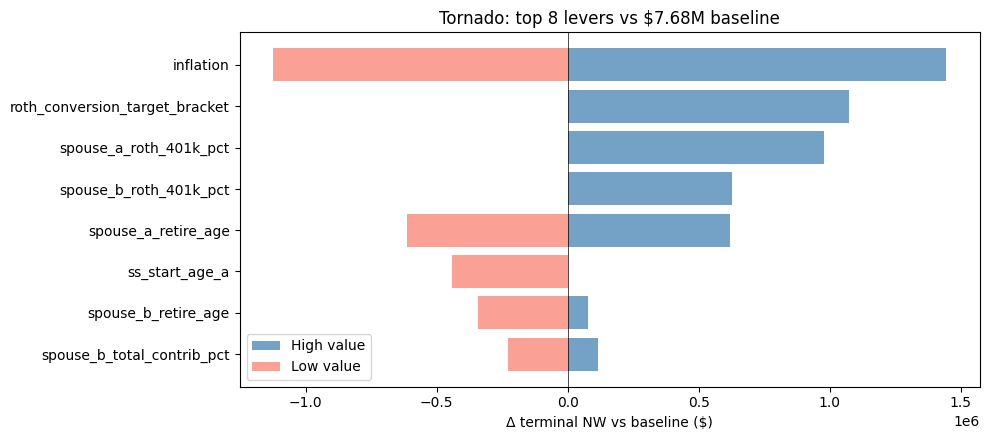

In [53]:
sens_df, base_terminal = tornado_sensitivity(cfg, inputs)

print(f"Base terminal NW (S0): ${base_terminal:,.0f}\n")
display(sens_df.head(10).round(0))

top = sens_df.head(8).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(top["param"], top["delta_high"], color="steelblue", alpha=0.75, label="High value")
ax.barh(top["param"], top["delta_low"],  color="salmon",    alpha=0.75, label="Low value")
ax.axvline(0, color="black", linewidth=0.5)
ax.set_title(f"Tornado: top 8 levers vs ${base_terminal/1e6:.2f}M baseline")
ax.set_xlabel("\u0394 terminal NW vs baseline ($)")
ax.legend()
plt.tight_layout()
plt.show()

## §8. Monte Carlo &mdash; sequence-of-returns risk

The deterministic numbers above assume a single fixed return path. Real
markets aren't kind enough to deliver that. Re-run the winning strategy
under **300 stochastic paths** drawn from the lognormal market model
(with equity-bond correlation) and look at the distribution.

After 300 stochastic paths:
  P(success)            = 94.7%
  Median terminal NW    = $9,986,031
  10th-pct terminal NW  = $1,571,986
  90th-pct terminal NW  = $30,468,076
  CVaR(10%)             = $435,716


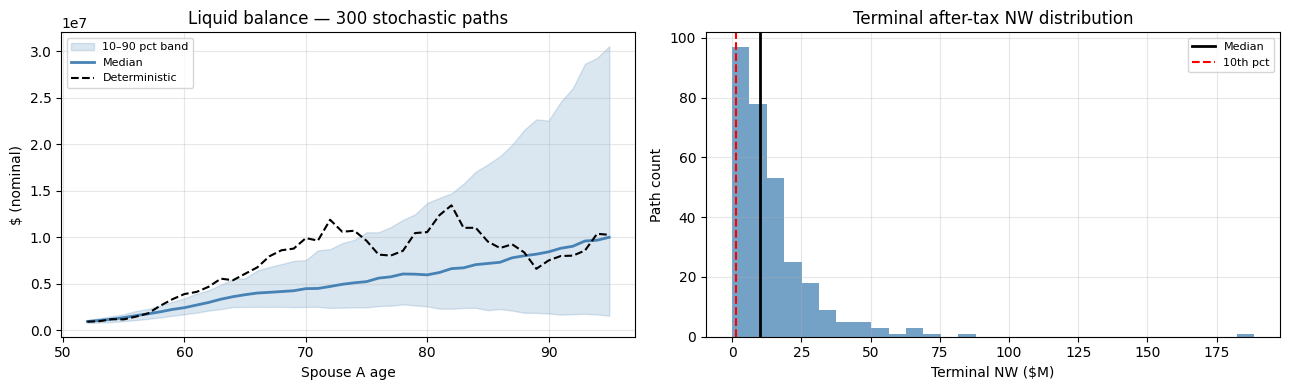

In [54]:
mc_cfg = replace(winner.cfg, market=LognormalModel(equity_bond_corr=0.10))
mc = simulate_paths(mc_cfg, winner.inputs, n_paths=300, seed=42, keep_paths=True)

print(f"After {len(mc.terminals)} stochastic paths:")
print(f"  P(success)            = {mc.prob_success():.1%}")
print(f"  Median terminal NW    = ${np.median(mc.terminals):,.0f}")
print(f"  10th-pct terminal NW  = ${np.percentile(mc.terminals, 10):,.0f}")
print(f"  90th-pct terminal NW  = ${np.percentile(mc.terminals, 90):,.0f}")
print(f"  CVaR(10%)             = ${mc.cvar_terminal(0.10):,.0f}")

liq = np.array([(p["pretax_balance"] + p["roth_balance"] + p["taxable_balance"]).values for p in mc.paths])
ages_axis = np.arange(liq.shape[1]) + winner.inputs.spouse_a_age_start
p10, p50, p90 = (np.percentile(liq, q, axis=0) for q in (10, 50, 90))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.fill_between(ages_axis, p10, p90, alpha=0.20, color="steelblue", label="10\u201390 pct band")
ax.plot(ages_axis, p50, color="steelblue", linewidth=2, label="Median")
ax.plot(ages_axis, winner.df["pretax_balance"] + winner.df["roth_balance"] + winner.df["taxable_balance"],
        color="black", linewidth=1.5, linestyle="--", label="Deterministic")
ax.set_title("Liquid balance \u2014 300 stochastic paths")
ax.set_xlabel("Spouse A age")
ax.set_ylabel("$ (nominal)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(mc.terminals / 1e6, bins=30, color="steelblue", alpha=0.75)
ax.axvline(np.median(mc.terminals) / 1e6, color="black", linewidth=2, label="Median")
ax.axvline(np.percentile(mc.terminals, 10) / 1e6, color="red", linewidth=1.5, linestyle="--", label="10th pct")
ax.set_title("Terminal after-tax NW distribution")
ax.set_xlabel("Terminal NW ($M)")
ax.set_ylabel("Path count")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## §9. Widow's-penalty stress test

Re-run the winning strategy under "Spouse A passes mid-retirement".
Filing status switches to single (after the year of death) and the
brackets compress &mdash; the survivor often pays a higher marginal rate
on a smaller income. The simulator uses the v5 fixes:

- year of death is filed MFJ (per the IRS rule),
- survivor SS is available starting at age 60,
- step-up in basis is applied if `cfg.stepup_at_first_death=True`.

,terminal_after_tax,lifetime_tax_npv,lifetime_irmaa_npv,peak_marginal
Both alive (winner),"10,245,351","1,279,809","16,364",28%
Widow @ year 20,"10,164,046","1,106,807","12,155",28%


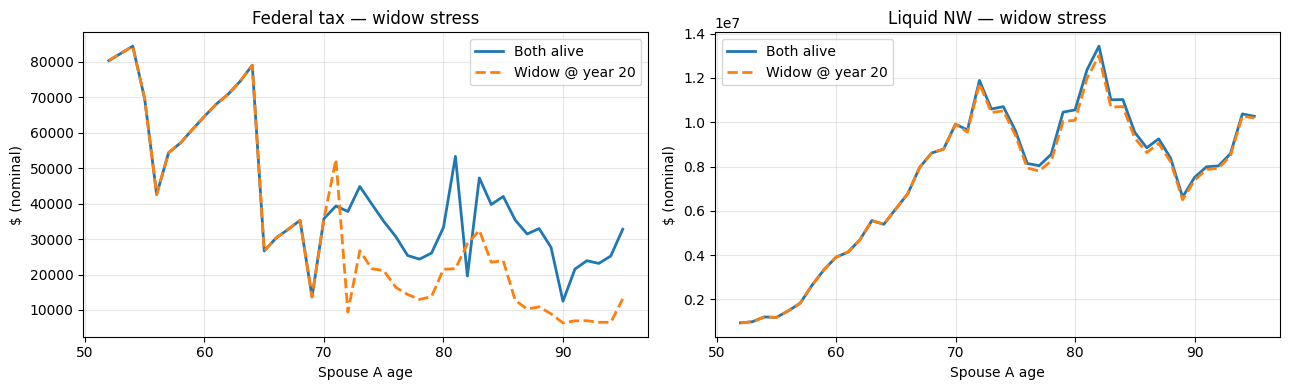

In [55]:
retire_year = max(winner.inputs.spouse_a_retire_age, winner.inputs.spouse_b_retire_age) - winner.inputs.spouse_a_age_start
widow_year = retire_year + 5

widow_cfg = replace(
    winner.cfg,
    mortality=Mortality(year_of_death_a=widow_year, pension_survivor_pct=0.5),
    stepup_at_first_death=True,
)
df_widow = simulate(widow_cfg, winner.inputs)

cmp = pd.DataFrame({
    "Both alive (winner)":         summarize(winner.df,  heir_marginal_rate=winner.cfg.heir_marginal_rate),
    f"Widow @ year {widow_year}":  summarize(df_widow,   heir_marginal_rate=widow_cfg.heir_marginal_rate),
}).T[["terminal_after_tax", "lifetime_tax_npv", "lifetime_irmaa_npv"]]
cmp_disp = cmp.round(0).copy()
cmp_disp["peak_marginal"] = [f"{summarize(winner.df)['peak_marginal']:.0%}", f"{summarize(df_widow)['peak_marginal']:.0%}"]
display(cmp_disp)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(winner.df["spouse_a_age"], winner.df["federal_tax"], label="Both alive", linewidth=2)
axes[0].plot(df_widow["spouse_a_age"], df_widow["federal_tax"], label=f"Widow @ year {widow_year}", linewidth=2, linestyle="--")
axes[0].set_title("Federal tax \u2014 widow stress")
axes[0].set_xlabel("Spouse A age")
axes[0].set_ylabel("$ (nominal)")
axes[0].legend()
axes[0].grid(alpha=0.3)

liq_b = winner.df["pretax_balance"] + winner.df["roth_balance"] + winner.df["taxable_balance"]
liq_w = df_widow["pretax_balance"] + df_widow["roth_balance"] + df_widow["taxable_balance"]
axes[1].plot(winner.df["spouse_a_age"], liq_b, label="Both alive", linewidth=2)
axes[1].plot(df_widow["spouse_a_age"], liq_w, label=f"Widow @ year {widow_year}", linewidth=2, linestyle="--")
axes[1].set_title("Liquid NW \u2014 widow stress")
axes[1].set_xlabel("Spouse A age")
axes[1].set_ylabel("$ (nominal)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## §10. TCJA sunset stress test

The example02 scenario already has TCJA sunsetting in year 5. How
sensitive is the plan to that timing? Here we compare three regimes:

- **Sunset year 0** &mdash; the worst case (rates pop immediately).
- **Sunset year 5** &mdash; the loaded scenario.
- **No sunset** &mdash; TCJA-extended forever (best case).

In [56]:
sunset_now = replace(winner.cfg, regime_change_year_offset=0,    regime_change_target=SUNSET_2026)
sunset_5   = replace(winner.cfg, regime_change_year_offset=5,    regime_change_target=SUNSET_2026)
no_sunset  = replace(winner.cfg, regime_change_year_offset=None, regime_change_target=None)

panel = pd.DataFrame({
    "Sunset year 0":           summarize(simulate(sunset_now, winner.inputs), heir_marginal_rate=winner.cfg.heir_marginal_rate),
    "Sunset year 5 (loaded)":  summarize(simulate(sunset_5,   winner.inputs), heir_marginal_rate=winner.cfg.heir_marginal_rate),
    "No sunset (best case)":   summarize(simulate(no_sunset,  winner.inputs), heir_marginal_rate=winner.cfg.heir_marginal_rate),
}).T
panel_disp = panel[["terminal_after_tax", "lifetime_tax_npv"]].round(0).copy()
panel_disp["peak_marginal"] = panel["peak_marginal"].apply(lambda x: f"{x:.0%}")
display(panel_disp)

base = panel.loc["Sunset year 5 (loaded)", "terminal_after_tax"]
print("\n\u0394 vs loaded scenario (terminal NW):")
print((panel["terminal_after_tax"] - base).round(0).to_string())

,terminal_after_tax,lifetime_tax_npv,peak_marginal
Sunset year 0,"8,985,781","1,633,201",28%
Sunset year 5 (loaded),"10,245,351","1,279,809",28%
No sunset (best case),"10,945,944","1,084,260",24%



Δ vs loaded scenario (terminal NW):
Sunset year 0            -1,259,571
Sunset year 5 (loaded)            0
No sunset (best case)       700,593


## §11. Tier&nbsp;C feature dial &mdash; ACA / step-up / state / IRMAA

A side-by-side comparison of the modeling features added in v5. Each
row toggles **one** knob from the loaded scenario; the &Delta; column
is the change in terminal NW vs the baseline (loaded scenario).

Use this to answer "how much does this feature actually move the needle
for *my* household?" before investing time in fine-tuning it.

> The "step-up" rows pair `stepup_at_first_death=True` with an early
> spouse-A death so the rule actually fires &mdash; the loaded scenario has
> both spouses dying simultaneously, where step-up is moot.

In [57]:
early_death = Mortality(year_of_death_a=widow_year, pension_survivor_pct=0.5)

dial = {
    "baseline":                       winner.cfg,
    "ACA enabled":                    replace(winner.cfg, aca_enabled=True),
    "Move to CA":                     replace(winner.cfg, state_regime=CA),
    "Move to NY":                     replace(winner.cfg, state_regime=NY),
    "IRMAA lookback off":             replace(winner.cfg, irmaa_lookback_years=0),
    "Pre-65 health $15k/yr":         replace(winner.cfg, health_pre65_today=15_000),
    f"Widow @ year {widow_year} (no step-up)": replace(winner.cfg, mortality=early_death),
    f"Widow @ year {widow_year} + step-up":    replace(winner.cfg, mortality=early_death, stepup_at_first_death=True),
}

panel = pd.DataFrame({
    name: summarize(simulate(c, winner.inputs), heir_marginal_rate=c.heir_marginal_rate)
    for name, c in dial.items()
}).T[["terminal_after_tax", "lifetime_tax_npv", "lifetime_irmaa_npv"]]

base_terminal_dial = panel.loc["baseline", "terminal_after_tax"]
panel["delta_vs_baseline"] = (panel["terminal_after_tax"] - base_terminal_dial).round(0)
display(panel.round(0))

,terminal_after_tax,lifetime_tax_npv,lifetime_irmaa_npv,delta_vs_baseline
baseline,"10,245,351","1,279,809","16,364",0
ACA enabled,"8,954,210","1,093,402","5,801","-1,291,141"
Move to CA,"8,801,319","1,081,866","5,801","-1,444,032"
Move to NY,"9,127,152","1,146,454","10,025","-1,118,200"
IRMAA lookback off,"10,271,208","1,280,703","7,906","25,857"
Pre-65 health $15k/yr,"9,446,945","1,161,087","10,025","-798,406"
Widow @ year 20 (no step-up),"9,606,133","1,293,249","36,425","-639,218"
Widow @ year 20 + step-up,"10,164,046","1,106,807","12,155","-81,305"


## §12. Decision-ready action report

The package's `build_action_report` renders a clean Markdown summary
combining the strategy comparison, sensitivity findings, Monte Carlo
results, and concrete recommendations for the next 1&ndash;3 years.
This is the artifact you'd share with a tax advisor.

In [58]:
report_md = build_action_report(
    winner.cfg, winner.inputs, results, sens_df, base_terminal,
    mc=mc, scenario_path=str(scenario_path),
)
display(Markdown(report_md))

# Retirement Tax Optimization — Action Plan

_44-year horizon, ages 52/50 to 95, tax regime `TCJA_extended_2026`._

_Scenario file: `scenarios/example01.json`._

## TL;DR

**Verdict:** `S3_optimizer` beats `S0_baseline` by **$2,568,404** (+33.5%) in terminal after-tax NW.

_No lever changes recommended: your current inputs already match the optimizer's choice on every decision axis._

**Key risk readings:**
- P(success) under 300 stochastic paths: **94.7%** (safe)
- CVaR(10%) terminal NW: $435,716
- Peak federal marginal rate: **28%**
- Lifetime federal tax NPV: $1,279,809 (-277,085 vs S0)
- Lifetime IRMAA NPV: $16,364 (-41,759 vs S0)

## 1. Household snapshot

| Item | Value |
|---|---:|
| Spouse A age (retire / SS) | 52 (65 / 70) |
| Spouse B age (retire / SS) | 50 (67 / 67) |
| Combined gross W-2 income | $250,000 |
| Annual expenses (today's $) | $95,000 |
| Total liquid + retirement assets | $855,000 |
| &nbsp;&nbsp;&nbsp; Spouse A pretax (401k + IRA) | $400,000 |
| &nbsp;&nbsp;&nbsp; Spouse B pretax (401k + IRA) | $250,000 |
| &nbsp;&nbsp;&nbsp; Roth (both spouses, pooled) | $60,000 |
| &nbsp;&nbsp;&nbsp; Taxable brokerage | $120,000 |
| &nbsp;&nbsp;&nbsp; HSA / pension cash-balance | $25,000 / $0 |
| Employer 401(k) match (A / B) | 50% on first 6% / 50% on first 6% |

### Assumptions driving this plan

| Assumption | Value |
|---|---|
| Heir marginal tax rate (pretax / HSA bequest haircut) | 22% |
| Inflation | 2.5%/yr |
| Nominal growth (deterministic baseline) | 6.0%/yr |
| Market model | LognormalModel (equity μ=7.0%/σ=18.0%, bond μ=4.0%/σ=6.0%, ρ=0.10) |
| Federal tax regime | `TCJA_extended_2026` → `tcja_sunset_2026` in year 5 |
| State tax regime | `stateless` |
| Mortality | Spouse A: year 30, Spouse B: year None (horizon = year 44) |
| Step-up in basis at first death | off |
| ACA premium tax credit | disabled |
| Pre-65 healthcare (today's $) | $0/yr |
| Medicare base premium (today's $) | $2,500/yr |
| IRMAA MAGI lookback | 2 year(s) |

### Tax-regime change

_Federal regime steps from `TCJA_extended_2026` to `tcja_sunset_2026` in year 5 (calendar 2031)._

| Metric | Last year of old regime | First year of new regime | Δ |
|---|---:|---:|---:|
| Calendar year | 2030 | 2031 | — |
| AGI | $278,826 | $282,533 | $+3,707 |
| Peak marginal rate | 24% | 28% | +4.0pp |
| Federal tax | $42,587 | $54,399 | $+11,812 |

### Widow's-penalty risk

_Spouse A dies year 30 (calendar 2056). Filing status switches to single in year 31 (calendar 2057). Survivor (Spouse B) files single for the remaining 13 year(s)._

| Metric | Last MFJ year | First single year | Δ |
|---|---:|---:|---:|
| AGI | $282,152 | $306,758 | $+24,606 |
| Peak marginal rate | 15% | 25% | +10.0pp |
| Federal tax | $19,582 | $47,274 | $+27,693 |

## 2. Recommended plan

**Winning strategy:** `S3_optimizer`

| Lever | Recommended | Currently |
|---|---:|---:|
| Spouse A Roth share of deferral | 100% | 100% |
| Spouse B Roth share of deferral | 100% | 100% |
| Roth conversion target bracket (gap years) | 24% | 24% |

### Why the optimizer chose this

- **Heir-rate framing:** your heir marginal rate (22%) meets-or-exceeds your average retirement marginal (17%). Each pretax dollar you do *not* convert will be taxed at 22% on the bequest, so converting now (paying ≤ 17%) locks in a cheaper rate. Hence the 24% conversion target.
- **Sunset front-loading:** the federal regime steps to `tcja_sunset_2026` in year 5 (calendar 2031); brackets compress and rates rise. Concentrating Roth conversions *before* the boundary locks in current-law rates.
- **Bucket imbalance:** your pretax balance is 11× your Roth balance ($650,000 vs $60,000). The optimizer raises Roth-401(k) share and conversions to rebalance — left unchecked, RMDs on a 11× pretax pile push you into IRMAA and the 32-37% bracket every year after age 75.

## 3. Expected outcomes (deterministic, point-estimate)

_Best value in each row is **bolded**. Higher is better for terminal NW; lower is better for tax, IRMAA, peak marginal._

| Metric | S0 baseline | S1 all roth | S2 bracket fill 22 | S3 optimizer |
|---|---:|---:|---:|---:|
| Terminal after-tax NW | $7,676,948 | $9,265,230 | $7,807,899 | **$10,245,351** |
| Lifetime federal tax (NPV) | $1,556,893 | $1,612,588 | $1,513,587 | **$1,279,809** |
| Lifetime IRMAA (NPV) | $58,123 | $57,056 | $51,769 | **$16,364** |
| Peak federal marginal rate | 28% | 28% | 28% | 28% |
| Years with IRMAA | 16 | 17 | 16 | **8** |
| Peak IRMAA tier | 4 | 4 | 4 | **3** |

_Peak federal marginal year (for `S3_optimizer`): age **57**, AGI ~$282,533, marginal **28%**._

### Sensitivity to the heir-tax assumption

_The optimizer's verdict depends on how aggressively you discount terminal pretax dollars by the heir's eventual tax bill (see the `Assumptions driving this plan` block). The plan stays the same in each row below — we just re-score it at a different heir rate, so you can see how robust the answer is to your view of future tax rates._

| Heir marginal rate | Terminal after-tax NW | Δ vs current |
|---:|---:|---:|
| **10%** | $10,257,465 | $+12,114 |
| **22%**  ← current assumption | $10,245,351 | — |
| **32%** | $10,235,257 | $-10,095 |
| **37%** | $10,230,209 | $-15,142 |

## 4. Risk picture (Monte Carlo)

_Based on 300 stochastic paths under the `LognormalModel` market model._

| Metric | Value | Reading |
|---|---:|---|
| Probability of success | 94.7% | safe |
| Terminal NW p5 / p50 / p95 | $202,858 / $9,986,031 / $43,379,894 | spread of bad-to-good outcomes |
| CVaR(10%) terminal | $435,716 | expected NW in the worst 10% of paths |
| Median lifetime tax (NPV) | $1,074,517 | — |
| Median ruin year | 38 | **at least half of failure paths run out by year 38** |

## 5. Highest-leverage levers (top 3 by tornado swing)

| Knob | Range tested | Best direction | $ swing |
|---|---|---|---:|
| `inflation` | 2% → 4% | higher (+$1,444,742) | $1,444,742 |
| `roth_conversion_target_bracket` | $0 → $0 | higher (+$1,073,003) | $1,073,003 |
| `spouse_a_roth_401k_pct` | 0% → 100% | higher (+$976,789) | $976,789 |

## 6. Year-by-year action timeline

### This year's concrete actions (calendar year 2026)

_Year-1 dollar amounts from the optimized plan. Use these to set up payroll deductions and HSA / brokerage transfers immediately._

- **401(k) employee deferral:** Spouse A $14,000 (100% Roth) + Spouse B $7,600 (100% Roth) = **$21,600 total**
- **Employer 401(k) match (free money):** Spouse A $4,200 + Spouse B $2,850 = **$7,050 total**
- **HSA:** $8,550
- **Roth conversion (pretax → Roth):** $191,436 — pay the conversion tax from taxable, not from the converted amount

**Expected year-1 tax bill:** federal $80,394 + state $0 + FICA $17,806 = **$98,200**

### Multi-decade phases

| Phase | Ages (Spouse A) | What to do |
|---|---|---|
| **Accumulation** | 52–64 | Defer 10% of A's salary (100% Roth / 0% Traditional) and 8% of B's (100% Roth / 0% Traditional). Max HSA. Build 1–2 years' expenses in taxable as IRMAA buffer. |
| **Gap years (conversion window)** | 67–74 | No wages and SS not yet started → fill the 24% bracket each year via pretax → Roth conversions. Pay conversion tax from taxable. |
| **Medicare / IRMAA** | 65+ | IRMAA tiers depend on AGI from **2 years prior**. Watch the 22% / 24% bracket and the IRMAA cliffs at 65, 67. |
| **SS claim** | 67 | Both spouses begin Social Security ($67,200/yr today). After this, conversion-window income includes SS. |
| **RMDs begin** | 75 | Required minimum distributions hit Spouse A's pretax balance. Spouse B's RMDs follow on B's schedule. Reduce or stop conversions. |
| **Drawdown** | 76–95 | Withdrawal sequence: `conventional`. Take RMDs first, then top up from taxable / Roth as needed. |

## 7. Year-by-year withdrawal & conversion plan

_Full horizon: every simulated year from start age through the horizon. Pre-retirement rows (below the row marked **RETIRE @ 65**) carry meaningful AGI / federal tax / state tax columns even though withdrawal columns are mostly empty — useful to see when contributions phase into drawdown and to spot any pre-retirement Roth conversions. Cells with no activity render as `—`. Pass `year_table_scope="retirement"` (or `--year-table-scope retirement`) to collapse to retirement-only._

| Age (A) | Pretax W/D | Roth conv. | Roth W/D | Taxable W/D | RMD | AGI | Fed tax | IRMAA | Health $ |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 52 | — | $191,436 | — | — | — | $426,800 | $80,394 | — | — |
| 53 | — | $193,617 | — | — | — | $437,470 | $82,403 | — | — |
| 54 | — | $196,024 | — | — | — | $448,407 | $84,462 | — | — |
| 55 | — | $126,762 | — | — | — | $388,772 | $69,568 | — | — |
| 56 | — | $7,935 | — | — | — | $278,826 | $42,587 | — | — |
| 57 | — | — | — | — | — | $282,533 | $54,399 | — | — |
| 58 | — | — | — | — | — | $294,797 | $57,152 | — | — |
| 59 | — | — | — | — | — | $311,186 | $60,971 | — | — |
| 60 | — | — | — | — | — | $327,124 | $64,662 | — | — |
| 61 | — | — | — | — | — | $342,287 | $68,139 | — | — |
| 62 | — | — | — | — | — | $354,920 | $70,946 | — | — |
| 63 | — | — | — | — | — | $370,831 | $74,596 | — | — |
| 64 | — | — | — | — | — | $389,965 | $79,076 | — | — |
| **RETIRE @ 65** | | | | | | | | | |
| 65 | — | — | — | $61,853 | — | $214,208 | $26,663 | $3,644 | $3,446 |
| 66 | — | — | — | $79,601 | — | $237,402 | $30,334 | $3,735 | $3,532 |
| 67 | — | — | — | $75,020 | — | $252,419 | $32,758 | — | $7,241 |
| 68 | — | — | — | $65,539 | — | $263,873 | $35,278 | — | $7,423 |
| 69 | — | — | — | $174,286 | — | $233,871 | $13,672 | — | $7,608 |
| 70 | — | — | — | $194,525 | — | $310,096 | $35,817 | — | $7,798 |
| 71 | — | — | — | $200,672 | — | $327,974 | $39,342 | — | $7,993 |
| 72 | — | — | — | $204,260 | — | $324,048 | $37,801 | — | $8,193 |
| 73 | — | — | — | $212,428 | — | $357,194 | $44,858 | — | $8,398 |
| 74 | — | — | — | $214,510 | — | $338,846 | $39,914 | — | $8,608 |
| 75 | $5,933 | — | — | $166,644 | $5,933 | $311,284 | $35,015 | — | $8,823 |
| 76 | $5,355 | — | — | $168,596 | $5,355 | $295,979 | $30,761 | — | $9,044 |
| 77 | $8,639 | — | — | $166,249 | $8,639 | $272,910 | $25,374 | — | $9,270 |
| 78 | $8,563 | — | — | $169,546 | $8,563 | $271,197 | $24,348 | — | $9,501 |
| 79 | $9,121 | — | — | $174,132 | $9,121 | $281,708 | $26,067 | — | $9,739 |
| 80 | $11,187 | — | — | $180,792 | $11,187 | $316,144 | $33,307 | — | $9,982 |
| 81 | $11,294 | — | — | $379,403 | $11,294 | $426,068 | $53,359 | — | $10,232 |
| 82 | $12,908 | — | — | $175,799 | $12,908 | $282,152 | $19,582 | — | $5,244 |
| 83 | $14,024 | — | — | $195,796 | $14,024 | $306,758 | $47,274 | $9,082 | $5,375 |
| 84 | $11,581 | — | — | $202,027 | $11,581 | $274,520 | $39,772 | $2,319 | $5,509 |
| 85 | $11,618 | — | — | $231,708 | $11,618 | $288,402 | $42,041 | $5,971 | $5,647 |
| 86 | $10,161 | — | — | $235,369 | $10,161 | $260,092 | $35,400 | $2,437 | $5,788 |
| 87 | $9,472 | — | — | $238,898 | $9,471 | $244,046 | $31,445 | $2,498 | $5,933 |
| 88 | $9,959 | — | — | $245,623 | $9,959 | $253,644 | $32,978 | $2,560 | $6,081 |
| 89 | $9,059 | — | — | $248,429 | $9,059 | $230,972 | $27,676 | — | $6,233 |
| 90 | $7,144 | — | — | $243,288 | $7,143 | $160,251 | $12,471 | — | $6,389 |
| 91 | $8,164 | — | — | $257,074 | $8,164 | $206,767 | $21,541 | — | $6,549 |
| 92 | $8,660 | — | — | $265,293 | $8,660 | $221,144 | $23,905 | — | $6,713 |
| 93 | $8,658 | — | — | $271,435 | $8,657 | $220,177 | $23,144 | — | $6,880 |
| 94 | $9,187 | — | — | $279,746 | $9,187 | $233,374 | $25,243 | — | $7,052 |
| 95 | $11,008 | — | — | $291,719 | $11,008 | $273,204 | $32,798 | — | $7,229 |

_Pretax W/D = combined Spouse A + B pretax withdrawals; RMD = the IRS-required floor (A and B combined). Roth conversions show up as AGI in the same row but produce no cash to the household — they shift dollars from pretax → Roth and the conversion tax is paid from taxable. **Health $** = Medicare base premium + pre-65 healthcare − ACA premium tax credit; IRMAA stays as a separate column because it's a discrete AGI-cliff lever you can manage._

## 8. Always-good hygiene

- **Max the HSA each year** (triple tax-advantaged: deductible, tax-free growth, tax-free qualified withdrawals).
- **Hold 1–2 years of expenses in taxable** as an IRMAA / sequence-of-returns buffer; it lets you avoid IRA withdrawals in down-market years and to manage AGI around IRMAA cliffs.
- **Re-run this annually** with updated balances, salaries, and tax-regime assumptions. Roth-conversion targets in particular are very sensitive to bracket changes.
- **Beneficiary review:** primary + contingent on every account, including the HSA (which becomes ordinary income to a non-spouse beneficiary).

## 9. Caveats — what this plan does NOT model

- **State income tax** outside the bundled `STATELESS / CA / NY / IL / MA` presets. Add a custom `StateTaxRegime` for your state if it's not in this list.
- **Estate / inherited-IRA dynamics** beyond the flat `heir_marginal_rate` haircut on terminal pretax + HSA balances. SECURE Act 10-year drawdown timing for non-spouse heirs is not modeled.
- **Health-care shocks** beyond a single optional LTC stress test.
- **Tax-law revisions** beyond the bundled regimes (`TCJA_EXTENDED`, `PRE_TCJA_2017`, `SUNSET_2026`). Re-run with `cfg.tax_regime = SUNSET_2026` to stress-test current-law sunset.

_This is decision-support output, not tax/legal/investment advice. Consult a qualified professional before acting._

## §13. What's new in v5

The Tier&nbsp;C release added three classes of work, all exercised above:

**Correctness fixes (Tier&nbsp;C-A):**

| # | Fix | Where it shows up |
|---|---|---|
| TC-1 | Year-of-death filed MFJ | §9 widow stress |
| TC-2 | Survivor SS available at age 60 | §9 widow stress |
| TC-3 | Deficit-cascade marginal rate uses post-conversion AGI | §5 detail |
| TC-4 | Add'l Medicare 0.9% reconciled at household level | §3 sanity |
| TC-5 | Roth IRA MAGI uses prior-year AGI | §5 detail |
| TC-6 | Backdoor Roth pro-rata uses IRA-only sub-balance | §5 detail |
| TC-7 | Roth conversion respects RMD floor | §5 detail |
| TC-8 | Report shows per-spouse SS claim age | §12 report |
| TC-9 | Caveats block reflects implemented features | §12 report |

**Modeling additions (Tier&nbsp;C-B):**

| # | Addition | Where it shows up |
|---|---|---|
| TC-10 | Base Medicare Part B+D premium | §6 viz, §11 dial |
| TC-11 | IRMAA 2-year MAGI lookback | §11 dial |
| TC-12 | Pre-Medicare healthcare expense | §11 dial |
| TC-13 | ACA premium tax credit (post-IRA-2022) | §11 dial |
| TC-14 | Step-up in basis on first spouse's death | §9 widow, §11 dial |

**Optimizer extensions (Tier&nbsp;C-C):**

| # | Extension | Where it shows up |
|---|---|---|
| TC-15 | Mega-backdoor in decision vector | §4 S3 winner |
| TC-16 | Per-spouse SS claim age axis (when enabled) | §4 S3 winner |
| TC-17 | `mc_seed` thread-through for reproducible MC | §8 Monte Carlo |

For full details see [`CHANGELOG.md`](CHANGELOG.md) and
[`docs/scenario_guide.md`](docs/scenario_guide.md).